# Real World Classification

## Load data

Import the necessary libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [2]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## 3. Data Preprocessing

In [3]:
missing_cols = df.columns[df.isnull().any()]
print("Columns with missing values:", missing_cols)

Columns with missing values: Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'BranchLength'],
      dtype='object')


In [4]:
missing_cols = df.columns[df.isnull().any()]

before_stats = {}

for col in missing_cols:
    before_stats[col] = {
        "median": df[col].median(),
        "std": df[col].std()
    }

print("Columns with missing values before imputation:")
for col in missing_cols:
    print(f"{col}: median = {before_stats[col]['median']:.4f}, std = {before_stats[col]['std']:.4f}")

Columns with missing values before imputation:
SepalLengthCm: median = 6.3000, std = 1.0371
SepalWidthCm: median = 2.9000, std = 0.3896
PetalLengthCm: median = 5.0856, std = 1.5828
PetalWidthCm: median = 1.6000, std = 0.7067
BranchLength: median = 16.3000, std = 1.0352


In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    imputer = KNNImputer(n_neighbors=3)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

In [6]:
after_stats = {}

for col in missing_cols:
    after_stats[col] = {
        "median": df[col].median(),
        "std": df[col].std()
    }

print("Columns with missing values after KNN imputation:")

for col in missing_cols:
    print(f"{col}: median = {after_stats[col]['median']:.4f}, std = {after_stats[col]['std']:.4f}")

Columns with missing values after KNN imputation:
SepalLengthCm: median = 6.3000, std = 1.0106
SepalWidthCm: median = 2.9000, std = 0.3737
PetalLengthCm: median = 5.0595, std = 1.5791
PetalWidthCm: median = 1.7000, std = 0.6951
BranchLength: median = 16.3000, std = 1.0126


In [7]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.316800,2.840733,5.041200,1.685467,16.301400,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.010611,0.373732,1.579137,0.695148,1.012555,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.625000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.059472,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.100000,5.396403,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## 4. Data Exploration

In [8]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration

### Plot histogram

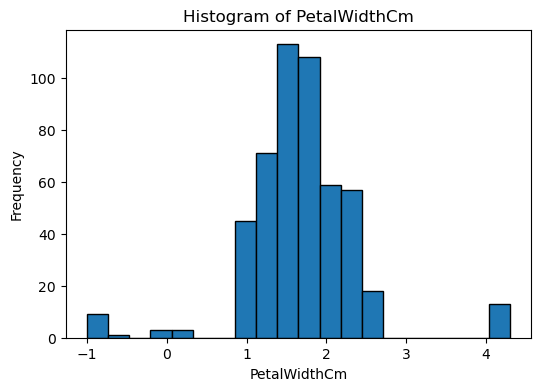

In [9]:
# Plot histogram
plt.figure(figsize=(6,4))
plt.hist(df['PetalWidthCm'], bins=20, edgecolor='black')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.title('Histogram of PetalWidthCm')
plt.show()

### List the feature with largest positive correlation

In [10]:
from sklearn.feature_selection import r_regression

# 選 feature（排除指定欄位）
features = df.drop(columns=['PetalWidthCm', 'Species', 'Id'])

# 目標變數
target = df['PetalWidthCm']

# 計算 Pearson correlation
correlations = r_regression(features, target)

# 對應欄位名稱
feature_names = features.columns

# 找最大正相關
max_index = correlations.argmax()
best_feature = feature_names[max_index]
best_corr = correlations[max_index]

print("Feature with the largest positive correlation:", best_feature)
print("Correlation value:", best_corr)

Feature with the largest positive correlation: PetalWidthCompactness
Correlation value: 0.9909526474865203


### Top 5 features with the strongest negative

In [11]:
# 排除欄位（避免 target & 非特徵）
exclude_cols = ['PetalWidthCm', 'Species', 'Id']

# 如果某些欄位不存在，避免 error
exclude_cols = [col for col in exclude_cols if col in df.columns]

features = df.drop(columns=exclude_cols)
target = df['PetalWidthCm']

# 計算 correlation
correlations = r_regression(features, target)

# 建 DataFrame
corr_df = pd.DataFrame({
    'Feature': features.columns,
    'Correlation': correlations
})

# 排序（由小到大 = 最負在前）
corr_df = corr_df.sort_values(by='Correlation', ascending=True)
# 取前 5 名（最負相關）
top5_negative = corr_df.head(5)

print("Top 5 features with the strongest negative correlations with PetalWidthCm:")

for _, row in top5_negative.iterrows():
    print(f"{row['Feature']:<25} {row['Correlation']:.6f}")

Top 5 features with the strongest negative correlations with PetalWidthCm:
SepalWidthMajorAxis       -0.097009
SepalGlossIndex           -0.093236
SepalWidthCompactness     -0.088006
SepalWidthCurvature       -0.081898
SepalWidthMinorAxis       -0.074390


### Plot the boxplot

In [12]:
# 取 feature 名稱
negative_features = top5_negative['Feature'].tolist()

# 合併（正 + 負）
plot_features = [best_feature] + negative_features

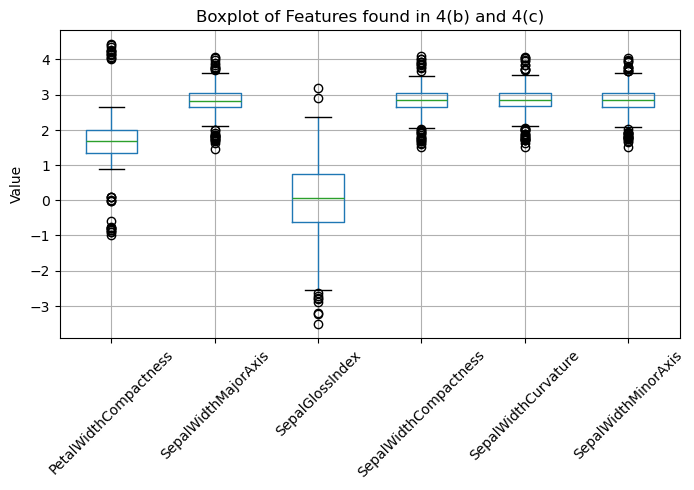

In [13]:
plt.figure(figsize=(8, 4))

df[plot_features].boxplot()

plt.title("Boxplot of Features found in 4(b) and 4(c)")
plt.xticks(rotation=45)
plt.ylabel("Value")

plt.show()

## Model Training

### Prepare the data

In [14]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.706667,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680000,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.613333,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320000,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520000,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

### No regularization

50. Training loss: 0.6184804227908781, Val loss:0.6387102099617076
100. Training loss: 0.5960515681671155, Val loss:0.6233491760136497
150. Training loss: 0.5781789344822855, Val loss:0.6115253885201725
200. Training loss: 0.5636207271102579, Val loss:0.6023016288379152
250. Training loss: 0.5515347923585762, Val loss:0.5950331970406951
300. Training loss: 0.5413367453753628, Val loss:0.5892648822066351
350. Training loss: 0.5326113619091207, Val loss:0.5846672770818119
400. Training loss: 0.5250567547151779, Val loss:0.5809966420161797
450. Training loss: 0.5184486473307285, Val loss:0.5780690237234178
500. Training loss: 0.5126170740304541, Val loss:0.5757431614864786
550. Training loss: 0.5074308761699786, Val loss:0.5739089271684022
600. Training loss: 0.5027871760815522, Val loss:0.5724793290181448
650. Training loss: 0.4986040882390972, Val loss:0.571384862463292
700. Training loss: 0.49481557562619033, Val loss:0.5705694404089225
750. Training loss: 0.4913677540894244, Val loss:

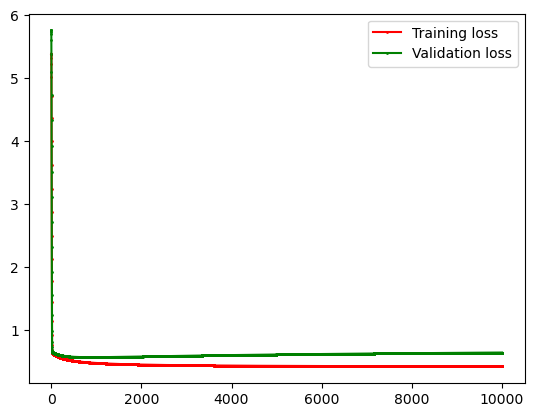

Model parameters (weights): [[-3.09567131e+00]
 [ 6.83960636e-01]
 [ 2.81398096e-01]
 [-8.52712036e-01]
 [ 1.01325107e+00]
 [-4.55741827e-03]
 [ 2.98290772e-01]
 [-2.45454183e-02]
 [ 2.22697980e-01]
 [ 1.90377816e+00]
 [ 8.94240300e-01]
 [ 7.63012757e-01]
 [ 1.17769496e+00]
 [ 2.07591364e-01]
 [-9.91673419e-01]
 [-8.87446740e-02]
 [ 1.61711440e+00]
 [ 7.16899424e-01]
 [ 1.64078969e-01]
 [ 2.07347682e-01]
 [ 2.85209787e-01]
 [ 5.09470289e-01]
 [-8.74032247e-02]
 [ 6.83994505e-01]
 [ 4.54659204e-01]
 [ 2.04127289e+00]
 [ 1.74400910e+00]
 [ 1.72092618e+00]
 [ 1.97984210e+00]
 [ 1.78647171e+00]
 [ 1.74924841e+00]
 [-2.28021049e+00]
 [ 1.42775047e+00]
 [-3.87731180e-01]
 [ 2.70550424e-01]
 [-1.49752292e+00]
 [ 6.05937815e-01]
 [-1.09392840e+00]
 [-3.02029620e+00]
 [-4.46972969e-01]
 [-1.23676970e+00]
 [-4.25489710e-01]
 [-9.74341111e-01]
 [-1.23603740e+00]
 [ 5.28746109e-01]
 [-3.29976879e-02]
 [ 3.02676496e-03]
 [ 2.91504148e-01]
 [-6.16822651e-01]
 [-6.68952162e-01]
 [-4.76003188e-01]
 [ 

In [15]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='', reg_lambda=0.0)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


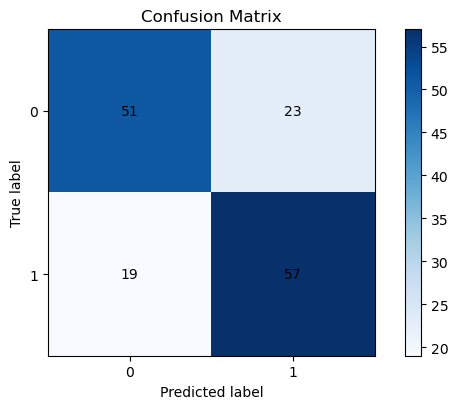

{'Accuracy': 0.72,
 'Precision': 0.7125,
 'Recall': 0.75,
 'F1-score': 0.7307692307692307}

In [16]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)

### L2 (reg_lambda=0.01)

50. Training loss: 0.6184885803999669, Val loss:0.6387137469835908
100. Training loss: 0.5960699934312756, Val loss:0.6233569033040084
150. Training loss: 0.5782086119381954, Val loss:0.6115371125154307
200. Training loss: 0.5636620307046659, Val loss:0.6023166641303569
250. Training loss: 0.5515877927393358, Val loss:0.5950505904517644
300. Training loss: 0.541401355158579, Val loss:0.5892835381743101
350. Training loss: 0.5326874055533007, Val loss:0.5846860317737743
400. Training loss: 0.5251440035173938, Val loss:0.5810143092610538
450. Training loss: 0.5185468383193816, Val loss:0.5780844244692819
500. Training loss: 0.5127259213630212, Val loss:0.5757551430281297
550. Training loss: 0.507550078918897, Val loss:0.5739163756695735
600. Training loss: 0.502916424119182, Val loss:0.5724811774490413
650. Training loss: 0.49874306695623816, Val loss:0.5713800953087489
700. Training loss: 0.49496396979749663, Val loss:0.5705570960619041
750. Training loss: 0.491525251030158, Val loss:0.

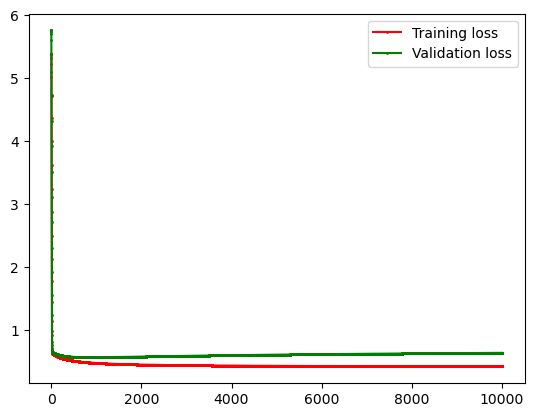

L2 (0.01) weights: [[-2.98198884]
 [ 0.6853736 ]
 [ 0.28829428]
 [-0.82501973]
 [ 1.02371149]
 [ 0.01734458]
 [ 0.29400427]
 [-0.00647546]
 [ 0.22872878]
 [ 1.84551302]
 [ 0.87508143]
 [ 0.74076385]
 [ 1.15284743]
 [ 0.19167734]
 [-0.96503122]
 [-0.07135644]
 [ 1.55042821]
 [ 0.69563329]
 [ 0.17156165]
 [ 0.19656836]
 [ 0.29326072]
 [ 0.51090401]
 [-0.07332623]
 [ 0.66422951]
 [ 0.43281985]
 [ 1.9932997 ]
 [ 1.71814726]
 [ 1.6929104 ]
 [ 1.93692771]
 [ 1.76265292]
 [ 1.71738746]
 [-2.224753  ]
 [ 1.39018632]
 [-0.38136879]
 [ 0.25725384]
 [-1.45286526]
 [ 0.59027738]
 [-1.07354531]
 [-2.95630573]
 [-0.43917565]
 [-1.21386774]
 [-0.42060074]
 [-0.96496064]
 [-1.2098602 ]
 [ 0.51342474]
 [-0.05039739]
 [-0.00369717]
 [ 0.27225942]
 [-0.6087524 ]
 [-0.66063342]
 [-0.4682225 ]
 [ 0.32416984]
 [ 0.16384095]
 [-0.59493879]
 [-0.38545336]
 [ 0.46791412]
 [-0.84804604]
 [-1.20460058]
 [-0.29230919]
 [ 0.5411794 ]
 [-0.99089807]
 [ 0.7292076 ]
 [ 0.5976887 ]
 [-1.56184686]
 [ 0.11605366]
 [ 1.1

In [17]:
np.random.seed(seed)

model_l2_001 = LinearModel(
    dim=X_train.shape[1],
    is_reg=True,
    loss_fn=loss_fn,
    act_fn=act_fn,
    grad_fn=grad_fn
)

model_l2_001.fit(
    X_train, y_train,
    lr=0.1,
    n_iteration=10000,
    val_ratio=0.2,
    reg_type='l2',
    reg_lambda=0.01
)

print("L2 (0.01) weights:", model_l2_001.W)
print("Sum of abs weights:", np.sum(np.abs(model_l2_001.W)))

L2 (lambda=0.01)
Model Evaluation
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


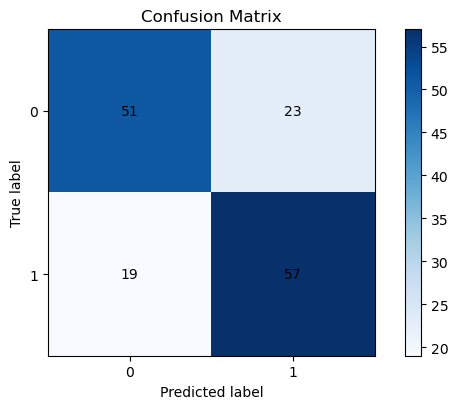

{'Accuracy': 0.72,
 'Precision': 0.7125,
 'Recall': 0.75,
 'F1-score': 0.7307692307692307}

In [18]:
y_pred_l2_001 = model_l2_001.predict(X_test)
y_pred_l2_001 = (y_pred_l2_001 > 0.5).astype(int)

print("L2 (lambda=0.01)")
evaluate_binary_classifier(y_test, y_pred_l2_001)

### L2 (reg_lambda=1)

50. Training loss: 0.6193114488211203, Val loss:0.6390915669694868
100. Training loss: 0.5979531492918615, Val loss:0.6242292648895962
150. Training loss: 0.5812717462953018, Val loss:0.6129324052420168
200. Training loss: 0.56795862881305, Val loss:0.6042114766918771
250. Training loss: 0.5571363651442208, Val loss:0.5973931360569834
300. Training loss: 0.5482008338640126, Val loss:0.592006996475839
350. Training loss: 0.5407250785185627, Val loss:0.587716483862493
400. Training loss: 0.5343998771273967, Val loss:0.5842756103184115
450. Training loss: 0.5289962330033694, Val loss:0.5815012451561112
500. Training loss: 0.5243411441254838, Val loss:0.5792548618721298
550. Training loss: 0.5203015742200391, Val loss:0.5774302228962703
600. Training loss: 0.5167736010435646, Val loss:0.5759448786198843
650. Training loss: 0.513674906661644, Val loss:0.5747341763624497
700. Training loss: 0.5109394732917703, Val loss:0.5737469589272894
750. Training loss: 0.5085137660257887, Val loss:0.572

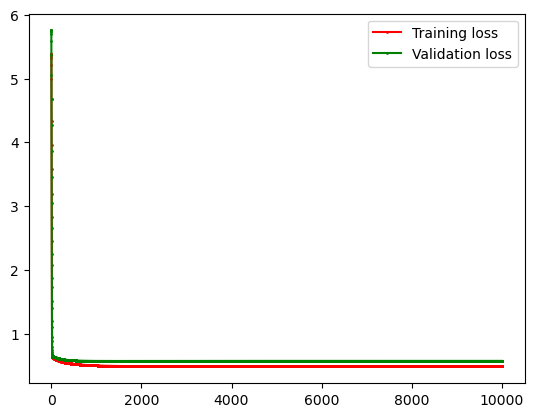

L2 (1) weights: [[-0.67336786]
 [ 0.46937696]
 [ 0.18558742]
 [-0.02379469]
 [ 0.83239832]
 [ 0.31718684]
 [ 0.20266904]
 [ 0.289223  ]
 [ 0.33203173]
 [ 0.5261097 ]
 [ 0.4049106 ]
 [ 0.38032602]
 [ 0.48072619]
 [ 0.02720854]
 [-0.14482496]
 [ 0.10426642]
 [ 0.24275093]
 [ 0.19080106]
 [ 0.13800534]
 [ 0.13277216]
 [ 0.22781948]
 [ 0.27974581]
 [ 0.15352863]
 [ 0.24720402]
 [ 0.1669344 ]
 [ 0.84963856]
 [ 0.86483022]
 [ 0.87014513]
 [ 0.88559974]
 [ 0.90658307]
 [ 0.87045839]
 [-0.71627261]
 [ 0.33798906]
 [-0.22153374]
 [-0.00620114]
 [-0.36770217]
 [ 0.07915461]
 [-0.45757968]
 [-1.16591526]
 [-0.18772172]
 [-0.50435873]
 [-0.21922444]
 [-0.56233548]
 [-0.43942381]
 [ 0.1013973 ]
 [-0.24128137]
 [-0.1724393 ]
 [-0.13852173]
 [-0.34647506]
 [-0.35855689]
 [-0.21433529]
 [-0.10958748]
 [-0.08412632]
 [-0.30145301]
 [-0.1272839 ]
 [ 0.05544592]
 [-0.41698803]
 [-0.58033077]
 [-0.24639422]
 [-0.08718299]
 [-0.55170145]
 [ 0.10784331]
 [ 0.17759855]
 [-0.62854805]
 [-0.18466542]
 [ 0.3014

In [19]:
np.random.seed(seed)

model_l2_1 = LinearModel(
    dim=X_train.shape[1],
    is_reg=True,
    loss_fn=loss_fn,
    act_fn=act_fn,
    grad_fn=grad_fn
)

model_l2_1.fit(
    X_train, y_train,
    lr=0.1,
    n_iteration=10000,
    val_ratio=0.2,
    reg_type='l2',
    reg_lambda=1
)

print("L2 (1) weights:", model_l2_1.W)
print("Sum of abs weights:", np.sum(np.abs(model_l2_1.W)))

L2 (lambda=1)
Model Evaluation
Accuracy  : 0.7400
Precision : 0.7342
Recall    : 0.7632
F1-score  : 0.7484


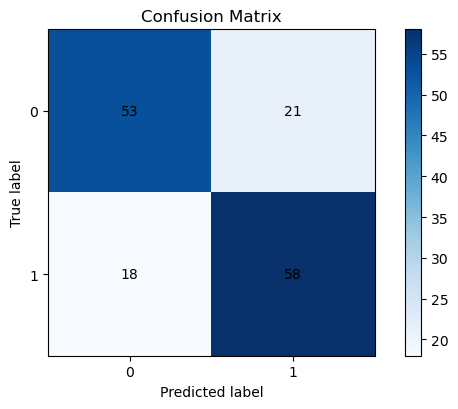

{'Accuracy': 0.74,
 'Precision': 0.7341772151898734,
 'Recall': 0.7631578947368421,
 'F1-score': 0.7483870967741936}

In [20]:
y_pred_l2_1 = model_l2_1.predict(X_test)
y_pred_l2_1 = (y_pred_l2_1 > 0.5).astype(int)

print("L2 (lambda=1)")
evaluate_binary_classifier(y_test, y_pred_l2_1)

### L2 (reg_lambda=100)

50. Training loss: 0.6737349146170288, Val loss:0.6828745851763008
100. Training loss: 0.6747017055877556, Val loss:0.683904021292684
150. Training loss: 0.6747209505199155, Val loss:0.6839259963329607
200. Training loss: 0.6747213303563705, Val loss:0.6839264632468401
250. Training loss: 0.6747213378722167, Val loss:0.6839264732411524
300. Training loss: 0.6747213380212881, Val loss:0.6839264734566578
350. Training loss: 0.6747213380242502, Val loss:0.683926473461337
400. Training loss: 0.6747213380243091, Val loss:0.6839264734614393
450. Training loss: 0.6747213380243103, Val loss:0.6839264734614414
500. Training loss: 0.6747213380243103, Val loss:0.6839264734614415
550. Training loss: 0.6747213380243103, Val loss:0.6839264734614415
600. Training loss: 0.6747213380243103, Val loss:0.6839264734614415
650. Training loss: 0.6747213380243103, Val loss:0.6839264734614415
700. Training loss: 0.6747213380243103, Val loss:0.6839264734614415
750. Training loss: 0.6747213380243103, Val loss:0.

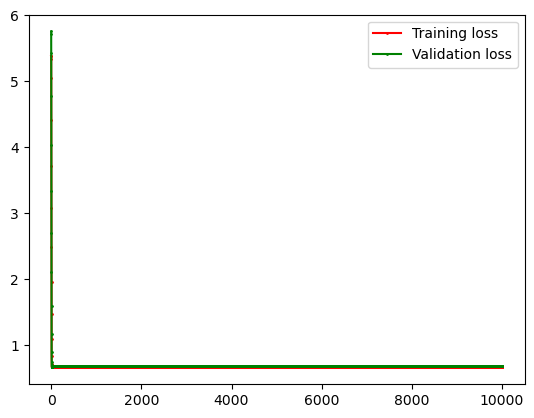

L2 (100) weights: [[-0.0125195 ]
 [ 0.02209092]
 [ 0.00792967]
 [ 0.02190124]
 [ 0.03683536]
 [ 0.01872949]
 [ 0.01768369]
 [ 0.01787653]
 [ 0.01922592]
 [ 0.02026676]
 [ 0.01913301]
 [ 0.0201246 ]
 [ 0.02093899]
 [ 0.00456558]
 [ 0.00309908]
 [ 0.00603561]
 [ 0.00703283]
 [ 0.00740943]
 [ 0.00625279]
 [ 0.0232541 ]
 [ 0.02383018]
 [ 0.02562945]
 [ 0.023887  ]
 [ 0.02517705]
 [ 0.02372747]
 [ 0.03461142]
 [ 0.03521082]
 [ 0.03661111]
 [ 0.03648092]
 [ 0.03669721]
 [ 0.03669341]
 [-0.01305973]
 [ 0.00454828]
 [-0.0064612 ]
 [-0.00240115]
 [-0.00520907]
 [-0.00337221]
 [-0.01244998]
 [-0.02755715]
 [-0.0052516 ]
 [-0.00985102]
 [-0.00412816]
 [-0.01540032]
 [-0.00701862]
 [-0.00177407]
 [-0.00553785]
 [-0.00864485]
 [-0.00525543]
 [-0.01146453]
 [-0.00883334]
 [-0.00135766]
 [-0.00758503]
 [-0.0063393 ]
 [-0.00801377]
 [-0.00212135]
 [-0.00161333]
 [-0.00840748]
 [-0.01319254]
 [-0.0086323 ]
 [-0.01062798]
 [-0.0152705 ]
 [-0.00044128]
 [ 0.00441002]
 [-0.01256757]
 [-0.0094543 ]
 [ 0.00

In [21]:
np.random.seed(seed)

model_l2_100 = LinearModel(
    dim=X_train.shape[1],
    is_reg=True,
    loss_fn=loss_fn,
    act_fn=act_fn,
    grad_fn=grad_fn
)

model_l2_100.fit(
    X_train, y_train,
    lr=0.1,
    n_iteration=10000,
    val_ratio=0.2,
    reg_type='l2',
    reg_lambda=100
)

print("L2 (100) weights:", model_l2_100.W)
print("Sum of abs weights:", np.sum(np.abs(model_l2_100.W)))

L2 (lambda=100)
Model Evaluation
Accuracy  : 0.5067
Precision : 0.5067
Recall    : 1.0000
F1-score  : 0.6726


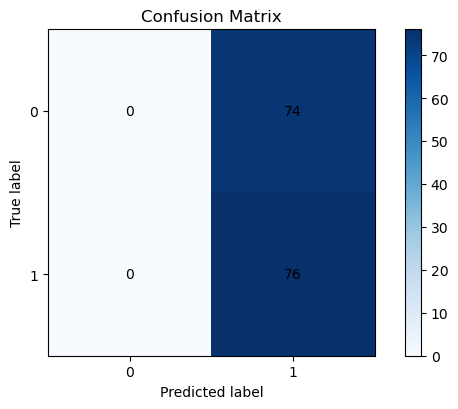

{'Accuracy': 0.5066666666666667,
 'Precision': 0.5066666666666667,
 'Recall': 1.0,
 'F1-score': 0.672566371681416}

In [22]:
y_pred_l2_100 = model_l2_100.predict(X_test)
y_pred_l2_100 = (y_pred_l2_100 > 0.5).astype(int)

print("L2 (lambda=100)")
evaluate_binary_classifier(y_test, y_pred_l2_100)